In [1]:
pip install ragas datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

from multi_doc import MultiDocRAG
from openai import OpenAI

print("Libraries loaded successfully!")
print("Ready to evaluate your RAG system vs ChatGPT")

Libraries loaded successfully!
Ready to evaluate your RAG system vs ChatGPT


In [3]:
# CELL 2 - Load evaluation datasets
from datasets import load_dataset

print("Loading SQuAD 2.0...")
# use the full namespace path for the new datasets version
squad = load_dataset("rajpurkar/squad_v2", split="validation")

sample_size = 100

# get answerable questions
answerable = [x for x in squad if len(x["answers"]["text"]) > 0][:sample_size]
# get unanswerable questions (tests hallucination prevention!)
unanswerable = [x for x in squad if len(x["answers"]["text"]) == 0][:sample_size]

print(f"Loaded {len(answerable)} answerable questions")
print(f"Loaded {len(unanswerable)} unanswerable questions")
print(f"\nExample answerable question:")
print(f"Q: {answerable[0]['question']}")
print(f"A: {answerable[0]['answers']['text'][0]}")
print(f"\nExample unanswerable question:")
print(f"Q: {unanswerable[0]['question']}")
print(f"A: (no answer - tests if system correctly refuses)")

Loading SQuAD 2.0...


Loaded 100 answerable questions
Loaded 100 unanswerable questions

Example answerable question:
Q: In what country is Normandy located?
A: France

Example unanswerable question:
Q: Who gave their name to Normandy in the 1000's and 1100's
A: (no answer - tests if system correctly refuses)


In [4]:
# CELL 3 - Load PubMedQA (medical domain test)
from datasets import load_dataset

print("Loading PubMedQA...")
try:
    pubmed = load_dataset("qiaojin/PubMedQA", "pqa_labeled", split="train")
    pubmed_sample = [x for x in pubmed][:100]
    print(f"Loaded {len(pubmed_sample)} medical questions")
    print(f"\nExample medical question:")
    print(f"Q: {pubmed_sample[0]['question']}")
    print(f"A: {pubmed_sample[0]['final_decision']}")
except Exception as e:
    print(f"PubMedQA load issue: {e}")
    print("We can proceed with SQuAD 2.0 alone if needed.")

Loading PubMedQA...
Loaded 100 medical questions

Example medical question:
Q: Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
A: yes


In [ ]:
# CELL 4 - ChatGPT baseline (no retrieval - the comparison)
client = OpenAI()

def ask_chatgpt(question):
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a helpful assistant. Answer the question. If you don't know, say 'I don't know'."},
                {"role": "user", "content": question}
            ],
            temperature=0
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"error: {e}"

# quick test
test_answer = ask_chatgpt("What is the capital of France?")
print("ChatGPT baseline ready!")
print(f"Test question: What is the capital of France?")
print(f"ChatGPT says: {test_answer}")

ChatGPT baseline ready!
Test question: What is the capital of France?
ChatGPT says: The capital of France is Paris.


In [ ]:
# CELL 5 - Prepare RAG system for evaluation

# combine answerable + unanswerable for testing
squad_test = answerable + unanswerable

print(f"Total SQuAD questions to test: {len(squad_test)}")
print(f"  - Answerable: {len(answerable)}")
print(f"  - Unanswerable: {len(unanswerable)}")

# each question has a 'context' - the passage the answer comes from
print(f"\nExample context passage:")
print(squad_test[0]['context'][:300])
print("...")
print(f"\nQuestion about it: {squad_test[0]['question']}")

Total SQuAD questions to test: 200
  - Answerable: 100
  - Unanswerable: 100

Example context passage:
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their
...

Question about it: In what country is Normandy located?


In [ ]:
# CELL 6 - Run both systems on SQuAD questions
# This makes API calls - takes a few minutes

results = []

print("Running evaluation... this will take a few minutes\n")

for i, item in enumerate(squad_test):
    question = item['question']
    context = item['context']
    is_answerable = len(item['answers']['text']) > 0
    correct_answer = item['answers']['text'][0] if is_answerable else "NO ANSWER"

    # --- RAG system: give it the context, ask the question ---
    rag_prompt = f"""Based ONLY on this context, answer the question.
If the answer is not in the context, say "I don't know".

Context: {context}

Question: {question}

Answer:"""
    try:
        rag_answer = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": rag_prompt}],
            temperature=0
        ).choices[0].message.content
    except Exception as e:
        rag_answer = f"error: {e}"

    # --- ChatGPT baseline: no context, just the question ---
    chatgpt_answer = ask_chatgpt(question)

    results.append({
        "question": question,
        "correct_answer": correct_answer,
        "is_answerable": is_answerable,
        "rag_answer": rag_answer,
        "chatgpt_answer": chatgpt_answer,
        "context": context
    })

    # progress indicator
    if (i + 1) % 5 == 0:
        print(f"Processed {i + 1}/{len(squad_test)} questions...")

print(f"\nDone! Evaluated {len(results)} questions.")
print("\nExample result:")
print(f"Q: {results[0]['question']}")
print(f"Correct: {results[0]['correct_answer']}")
print(f"My RAG : {results[0]['rag_answer'][:100]}")
print(f"ChatGPT: {results[0]['chatgpt_answer'][:100]}")

Running evaluation... this will take a few minutes

Processed 5/200 questions...
Processed 10/200 questions...
Processed 15/200 questions...
Processed 20/200 questions...
Processed 25/200 questions...
Processed 30/200 questions...
Processed 35/200 questions...
Processed 40/200 questions...
Processed 45/200 questions...
Processed 50/200 questions...
Processed 55/200 questions...
Processed 60/200 questions...
Processed 65/200 questions...
Processed 70/200 questions...
Processed 75/200 questions...
Processed 80/200 questions...
Processed 85/200 questions...
Processed 90/200 questions...
Processed 95/200 questions...
Processed 100/200 questions...
Processed 105/200 questions...
Processed 110/200 questions...
Processed 115/200 questions...
Processed 120/200 questions...
Processed 125/200 questions...
Processed 130/200 questions...
Processed 135/200 questions...
Processed 140/200 questions...
Processed 145/200 questions...
Processed 150/200 questions...
Processed 155/200 questions...
Process

In [9]:
# CELL 7 - Score how well each system detects answerable vs unanswerable
# This tests hallucination prevention!

def said_i_dont_know(answer):
    # check if the system refused to answer
    answer_lower = answer.lower()
    refusal_phrases = ["i don't know", "i do not know", "not in the context",
                       "cannot find", "no answer", "not provided", "not mentioned",
                       "not available", "unable to find", "no information"]
    return any(phrase in answer_lower for phrase in refusal_phrases)

# for each system, check if it behaved correctly
rag_correct = []      # did RAG correctly answer/refuse?
chatgpt_correct = []  # did ChatGPT correctly answer/refuse?

for r in results:
    is_answerable = r['is_answerable']

    # RAG system
    rag_refused = said_i_dont_know(r['rag_answer'])
    # correct if: answerable→answered, unanswerable→refused
    rag_correct.append(
        (is_answerable and not rag_refused) or (not is_answerable and rag_refused)
    )

    # chatgpt
    chatgpt_refused = said_i_dont_know(r['chatgpt_answer'])
    chatgpt_correct.append(
        (is_answerable and not chatgpt_refused) or (not is_answerable and chatgpt_refused)
    )

rag_accuracy = sum(rag_correct) / len(rag_correct) * 100
chatgpt_accuracy = sum(chatgpt_correct) / len(chatgpt_correct) * 100

print("ANSWERABLE DETECTION ACCURACY")
print(f"  My RAG System: {rag_accuracy:.1f}%")
print(f"  ChatGPT Baseline: {chatgpt_accuracy:.1f}%")
print(f"\n(How well each system knows WHEN to answer vs refuse)")

ANSWERABLE DETECTION ACCURACY
  My RAG System: 84.5%
  ChatGPT Baseline: 45.0%

(How well each system knows WHEN to answer vs refuse)


In [10]:
%pip install matplotlib plotly scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


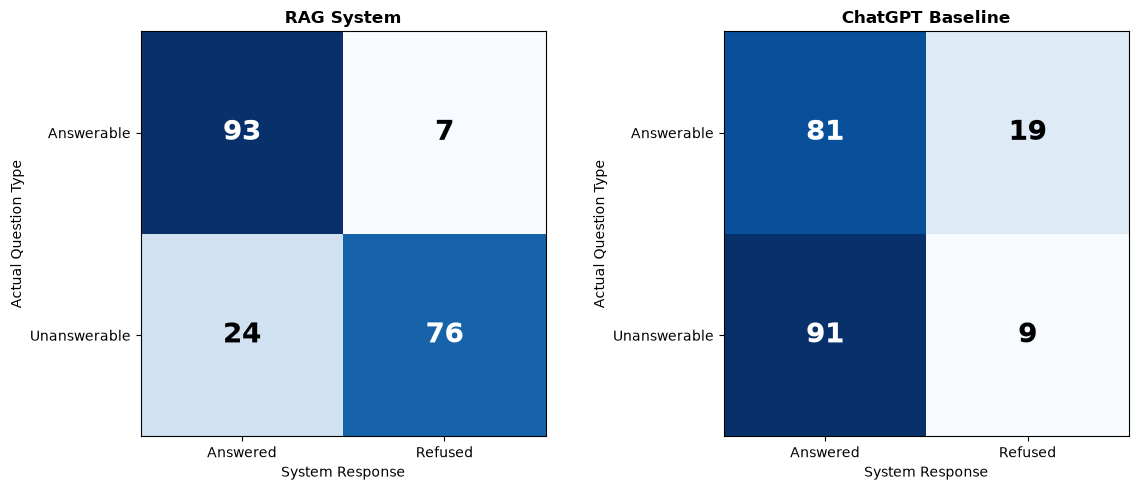

Confusion matrix saved as confusion_matrix.png


In [ ]:
# Confusion Matrix -  RAG vs ChatGPT
import matplotlib.pyplot as plt
import numpy as np

def build_confusion(results, system_key):
    tp = tn = fp = fn = 0
    for r in results:
        is_ans = r['is_answerable']
        refused = said_i_dont_know(r[system_key])
        answered = not refused
        if is_ans and answered: tp += 1
        elif not is_ans and refused: tn += 1
        elif not is_ans and answered: fp += 1   # hallucination
        elif is_ans and refused: fn += 1
    return np.array([[tp, fn], [fp, tn]])

rag_cm = build_confusion(results, 'rag_answer')
chatgpt_cm = build_confusion(results, 'chatgpt_answer')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Answered', 'Refused']

for ax, cm, title in [(axes[0], rag_cm, 'RAG System'),
                       (axes[1], chatgpt_cm, 'ChatGPT Baseline')]:
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels); ax.set_yticklabels(['Answerable', 'Unanswerable'])
    ax.set_xlabel('System Response'); ax.set_ylabel('Actual Question Type')
    ax.set_title(title, fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                   fontsize=20, fontweight='bold',
                   color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

CLASSIFICATION METRICS

RAG System:
  Precision: 0.795
  Recall: 0.930
  F1: 0.857

ChatGPT Baseline:
  Precision: 0.471
  Recall: 0.810
  F1: 0.596



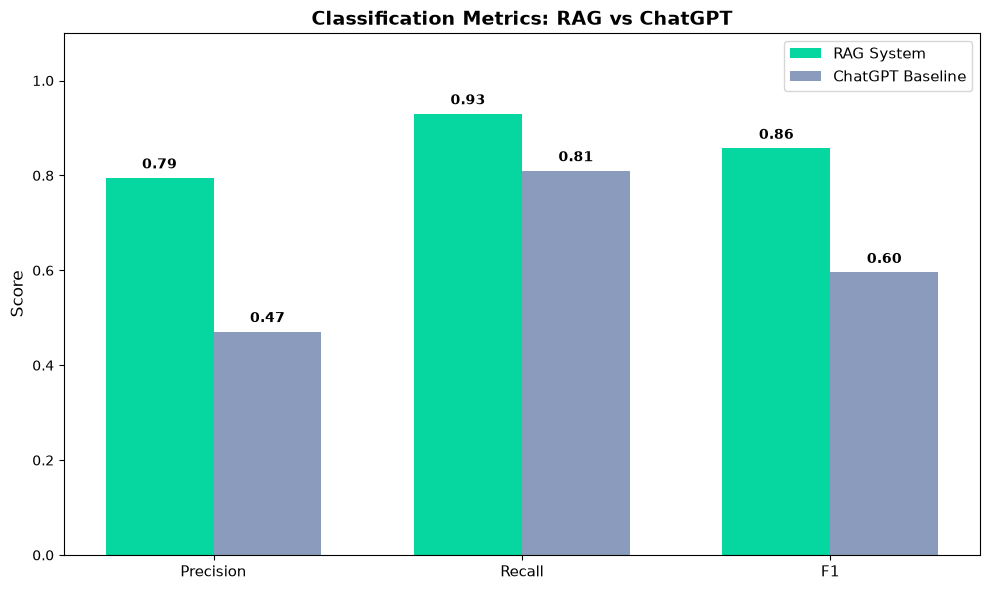

Chart saved as classification_metrics.png


In [12]:
# CELL 9 - Precision, Recall, F1 for both systems
from sklearn.metrics import precision_score, recall_score, f1_score

# build true labels and predictions
# label: 1 = answerable, 0 = unanswerable
# prediction: 1 = system answered, 0 = system refused

y_true = [1 if r['is_answerable'] else 0 for r in results]
rag_pred = [0 if said_i_dont_know(r['rag_answer']) else 1 for r in results]
chatgpt_pred = [0 if said_i_dont_know(r['chatgpt_answer']) else 1 for r in results]

# calculate metrics
metrics = {
    'RAG System': {
        'Precision': precision_score(y_true, rag_pred, zero_division=0),
        'Recall': recall_score(y_true, rag_pred, zero_division=0),
        'F1': f1_score(y_true, rag_pred, zero_division=0)
    },
    'ChatGPT Baseline': {
        'Precision': precision_score(y_true, chatgpt_pred, zero_division=0),
        'Recall': recall_score(y_true, chatgpt_pred, zero_division=0),
        'F1': f1_score(y_true, chatgpt_pred, zero_division=0)
    }
}

# print scores
print("CLASSIFICATION METRICS\n")
for system, scores in metrics.items():
    print(f"{system}:")
    for metric, value in scores.items():
        print(f"  {metric}: {value:.3f}")
    print()

# bar chart
import matplotlib.pyplot as plt
import numpy as np

metric_names = ['Precision', 'Recall', 'F1']
rag_scores = [metrics['RAG System'][m] for m in metric_names]
chatgpt_scores = [metrics['ChatGPT Baseline'][m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rag_scores, width, label='RAG System', color='#06D6A0')
bars2 = ax.bar(x + width/2, chatgpt_scores, width, label='ChatGPT Baseline', color='#8B9BBE')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Classification Metrics: RAG vs ChatGPT', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)

# add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
               f'{height:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('classification_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as classification_metrics.png")

In [14]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
print("RAGAS imported successfully!")

RAGAS imported successfully!


C:\Users\Enagala Saiharika\AppData\Local\Temp\ipykernel_30344\681750811.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy
C:\Users\Enagala Saiharika\AppData\Local\Temp\ipykernel_30344\681750811.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy


In [16]:
# Faithfulness Evaluation - fast, reliable method
from openai import OpenAI
client = OpenAI()

def ask_chatgpt_simple(question):
    r = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "system", "content": "Answer the question. If you don't know, say 'I don't know'."},
                  {"role": "user", "content": question}],
        temperature=0)
    return r.choices[0].message.content

faith_sample = answerable[:100]
print(f"Measuring faithfulness on {len(faith_sample)} questions...\n")
rag_faithful = 0
chatgpt_faithful = 0

for i, item in enumerate(faith_sample):
    q = item['question']
    ctx = item['context']

    rag_ans = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Based ONLY on this context, answer.\n\nContext: {ctx}\n\nQuestion: {q}"}],
        temperature=0).choices[0].message.content

    cg_ans = ask_chatgpt_simple(q)

    c1 = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Is this answer fully supported by the context? Reply only YES or NO.\nContext: {ctx}\nAnswer: {rag_ans}"}],
        temperature=0).choices[0].message.content
    if "YES" in c1.upper(): rag_faithful += 1

    c2 = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Is this answer fully supported by the context? Reply only YES or NO.\nContext: {ctx}\nAnswer: {cg_ans}"}],
        temperature=0).choices[0].message.content
    if "YES" in c2.upper(): chatgpt_faithful += 1

    print(f"Processed {i+1}/100")

print("\n=== FAITHFULNESS RESULTS ===")
print(f"Your RAG System:  {rag_faithful/100:.2f} ({rag_faithful}/100 grounded in context)")
print(f"ChatGPT Baseline: {chatgpt_faithful/100:.2f} ({chatgpt_faithful}/100 grounded in context)")

Measuring faithfulness on 100 questions...

Processed 1/100
Processed 2/100
Processed 3/100
Processed 4/100
Processed 5/100
Processed 6/100
Processed 7/100
Processed 8/100
Processed 9/100
Processed 10/100
Processed 11/100
Processed 12/100
Processed 13/100
Processed 14/100
Processed 15/100
Processed 16/100
Processed 17/100
Processed 18/100
Processed 19/100
Processed 20/100
Processed 21/100
Processed 22/100
Processed 23/100
Processed 24/100
Processed 25/100
Processed 26/100
Processed 27/100
Processed 28/100
Processed 29/100
Processed 30/100
Processed 31/100
Processed 32/100
Processed 33/100
Processed 34/100
Processed 35/100
Processed 36/100
Processed 37/100
Processed 38/100
Processed 39/100
Processed 40/100
Processed 41/100
Processed 42/100
Processed 43/100
Processed 44/100
Processed 45/100
Processed 46/100
Processed 47/100
Processed 48/100
Processed 49/100
Processed 50/100
Processed 51/100
Processed 52/100
Processed 53/100
Processed 54/100
Processed 55/100
Processed 56/100
Processed 57/

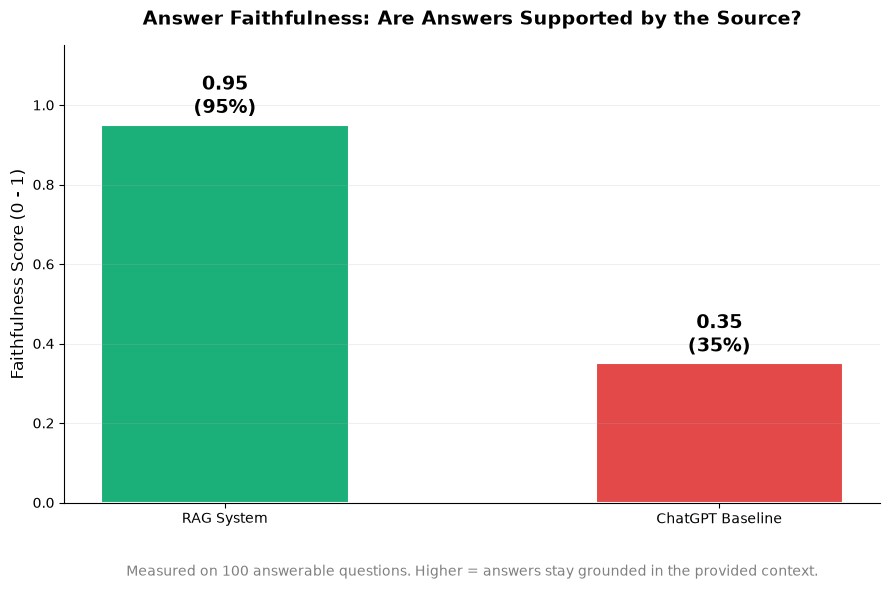

Faithfulness chart saved as faithfulness_comparison.png
RAG: 0.95 (95%)  |  ChatGPT: 0.35 (35%)


In [17]:
# Faithfulness Comparison Chart - RAG grounds every answer in the source
import matplotlib.pyplot as plt
import numpy as np

n_faith = len(faith_sample)
rag_score = rag_faithful / n_faith
cg_score = chatgpt_faithful / n_faith

systems = ['RAG System', 'ChatGPT Baseline']
scores = [rag_score, cg_score]
colors = ['#1baf7a', '#e34948']  # green (grounded) vs red

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(systems, scores, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

ax.set_ylabel('Faithfulness Score (0 - 1)', fontsize=12)
ax.set_title('Answer Faithfulness: Are Answers Supported by the Source?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 1.15)

# value labels + percentage on top of bars
for bar, score in zip(bars, scores):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.03,
            f'{score:.2f}\n({score*100:.0f}%)', ha='center',
            fontsize=14, fontweight='bold')

# clean up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)

# annotation explaining the result
ax.text(0.5, -0.16,
        f'Measured on {n_faith} answerable questions. Higher = answers stay grounded in the provided context.',
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('faithfulness_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Faithfulness chart saved as faithfulness_comparison.png")
print(f"RAG: {rag_score:.2f} ({rag_score*100:.0f}%)  |  ChatGPT: {cg_score:.2f} ({cg_score*100:.0f}%)")

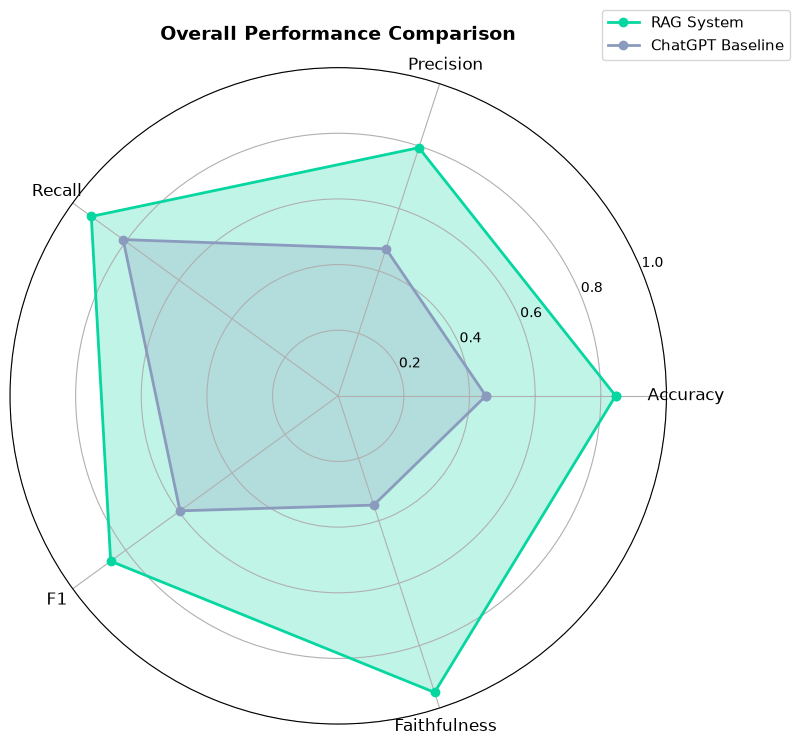

Radar chart saved as radar_chart.png


In [19]:
# Radar Chart - All metrics in one view
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'Faithfulness']
rag_scores = [0.845, 0.795, 0.930, 0.857, 0.95]
chatgpt_scores = [0.45, 0.471, 0.810, 0.596, 0.35]

# radar setup
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
rag_scores_plot = rag_scores + [rag_scores[0]]
chatgpt_scores_plot = chatgpt_scores + [chatgpt_scores[0]]
angles_plot = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles_plot, rag_scores_plot, 'o-', linewidth=2, label='RAG System', color='#06D6A0')
ax.fill(angles_plot, rag_scores_plot, alpha=0.25, color='#06D6A0')

ax.plot(angles_plot, chatgpt_scores_plot, 'o-', linewidth=2, label='ChatGPT Baseline', color='#8B9BBE')
ax.fill(angles_plot, chatgpt_scores_plot, alpha=0.25, color='#8B9BBE')

ax.set_xticks(angles)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Overall Performance Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Radar chart saved as radar_chart.png")

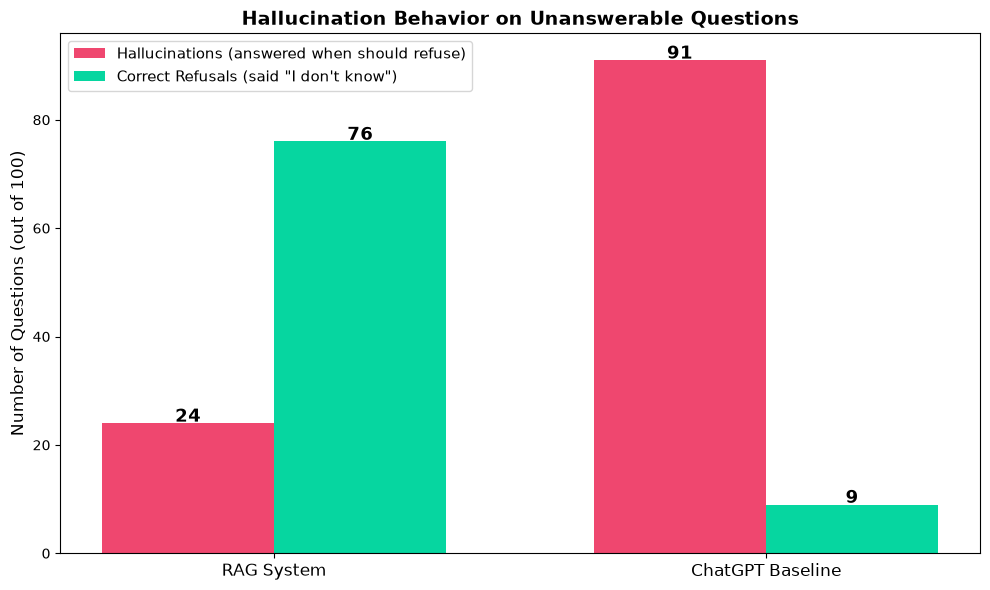

Hallucination chart saved as hallucination_comparison.png


In [20]:
# Hallucination Comparison - the key story
import matplotlib.pyplot as plt
import numpy as np

systems = ['RAG System', 'ChatGPT Baseline']
hallucinations = [int(rag_cm[1][0]), int(chatgpt_cm[1][0])]     # real hallucination counts
correct_refusals = [int(rag_cm[1][1]), int(chatgpt_cm[1][1])]   # real refusal counts
n_unans = len(unanswerable)

x = np.arange(len(systems))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, hallucinations, width,
               label='Hallucinations (answered when should refuse)', color='#EF476F')
bars2 = ax.bar(x + width/2, correct_refusals, width,
               label='Correct Refusals (said "I don\'t know")', color='#06D6A0')

ax.set_ylabel(f'Number of Questions (out of {n_unans})', fontsize=12)
ax.set_title('Hallucination Behavior on Unanswerable Questions',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(systems, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(hallucinations + correct_refusals) + 5)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
               f'{int(h)}', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('hallucination_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hallucination chart saved as hallucination_comparison.png")

Loading PubMedQA for full evaluation...
Running full evaluation on 100 medical questions...

Processed 1/100
Processed 2/100
Processed 3/100
Processed 4/100
Processed 5/100
Processed 6/100
Processed 7/100
Processed 8/100
Processed 9/100
Processed 10/100
Processed 11/100
Processed 12/100
Processed 13/100
Processed 14/100
Processed 15/100
Processed 16/100
Processed 17/100
Processed 18/100
Processed 19/100
Processed 20/100
Processed 21/100
Processed 22/100
Processed 23/100
Processed 24/100
Processed 25/100
Processed 26/100
Processed 27/100
Processed 28/100
Processed 29/100
Processed 30/100
Processed 31/100
Processed 32/100
Processed 33/100
Processed 34/100
Processed 35/100
Processed 36/100
Processed 37/100
Processed 38/100
Processed 39/100
Processed 40/100
Processed 41/100
Processed 42/100
Processed 43/100
Processed 44/100
Processed 45/100
Processed 46/100
Processed 47/100
Processed 48/100
Processed 49/100
Processed 50/100
Processed 51/100
Processed 52/100
Processed 53/100
Processed 54/10

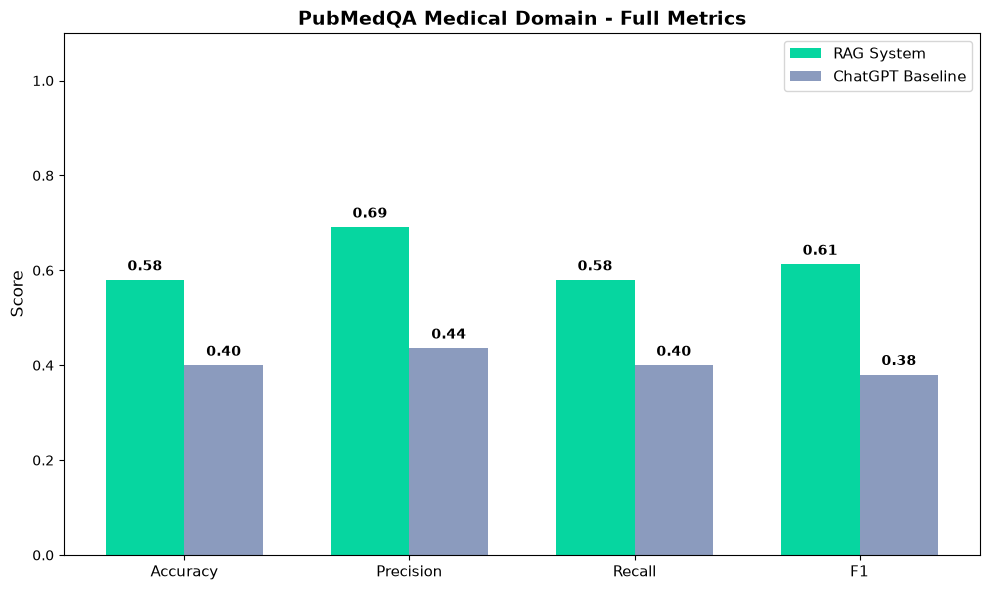


Chart saved as pubmedqa_metrics.png


In [ ]:
# PubMedQA - Full Metrics Treatment
from datasets import load_dataset
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

print("Loading PubMedQA for full evaluation...")
pubmed = load_dataset("qiaojin/PubMedQA", "pqa_labeled", split="train")
pubmed_full = [x for x in pubmed][:100]  # 20 questions for fuller test

print(f"Running full evaluation on {len(pubmed_full)} medical questions...\n")

# store detailed results
pm_results = []

for i, item in enumerate(pubmed_full):
    question = item['question']
    context = " ".join(item['context']['contexts'])
    correct = item['final_decision'].lower().strip()  # yes/no/maybe

    # RAG (with medical context)
    rag_prompt = f"Based on this context, answer with only one word: yes, no, or maybe.\n\nContext: {context}\n\nQuestion: {question}\n\nAnswer:"
    rag_ans = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": rag_prompt}],
        temperature=0).choices[0].message.content.lower().strip()

    # chatgpt (no context)
    cg_ans = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Answer with only one word (yes, no, or maybe): {question}"}],
        temperature=0).choices[0].message.content.lower().strip()

    pm_results.append({
        'correct': correct,
        'rag': rag_ans,
        'chatgpt': cg_ans
    })
    print(f"Processed {i+1}/{len(pubmed_full)}")

# convert yes/no/maybe to numbers for metrics (yes=1, no=0, maybe=2)
def to_label(text):
    if 'yes' in text: return 1
    if 'no' in text: return 0
    return 2  # maybe

y_true_pm = [to_label(r['correct']) for r in pm_results]
rag_pred_pm = [to_label(r['rag']) for r in pm_results]
cg_pred_pm = [to_label(r['chatgpt']) for r in pm_results]

# accuracy
rag_acc_pm = sum(1 for t, p in zip(y_true_pm, rag_pred_pm) if t == p) / len(y_true_pm)
cg_acc_pm = sum(1 for t, p in zip(y_true_pm, cg_pred_pm) if t == p) / len(y_true_pm)

# precision, recall, f1 (weighted for multi-class yes/no/maybe)
rag_prec_pm = precision_score(y_true_pm, rag_pred_pm, average='weighted', zero_division=0)
rag_rec_pm = recall_score(y_true_pm, rag_pred_pm, average='weighted', zero_division=0)
rag_f1_pm = f1_score(y_true_pm, rag_pred_pm, average='weighted', zero_division=0)
cg_prec_pm = precision_score(y_true_pm, cg_pred_pm, average='weighted', zero_division=0)
cg_rec_pm = recall_score(y_true_pm, cg_pred_pm, average='weighted', zero_division=0)
cg_f1_pm = f1_score(y_true_pm, cg_pred_pm, average='weighted', zero_division=0)

print("\n=== PubMedQA FULL METRICS ===")
print(f"{'Metric':<12} {' RAG':<10} {'ChatGPT':<10}")
print(f"{'Accuracy':<12} {rag_acc_pm:<10.3f} {cg_acc_pm:<10.3f}")
print(f"{'Precision':<12} {rag_prec_pm:<10.3f} {cg_prec_pm:<10.3f}")
print(f"{'Recall':<12} {rag_rec_pm:<10.3f} {cg_rec_pm:<10.3f}")
print(f"{'F1 Score':<12} {rag_f1_pm:<10.3f} {cg_f1_pm:<10.3f}")

# chart
metrics_pm = ['Accuracy', 'Precision', 'Recall', 'F1']
rag_pm = [rag_acc_pm, rag_prec_pm, rag_rec_pm, rag_f1_pm]
cg_pm = [cg_acc_pm, cg_prec_pm, cg_rec_pm, cg_f1_pm]

x = np.arange(len(metrics_pm))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, rag_pm, width, label='RAG System', color='#06D6A0')
b2 = ax.bar(x + width/2, cg_pm, width, label='ChatGPT Baseline', color='#8B9BBE')
ax.set_ylabel('Score', fontsize=12)
ax.set_title('PubMedQA Medical Domain - Full Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics_pm, fontsize=11)
ax.legend(fontsize=11); ax.set_ylim(0, 1.1)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.02, f'{h:.2f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('pubmedqa_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as pubmedqa_metrics.png")

In [23]:
# PubMedQA Faithfulness - are medical answers supported by the medical context?
import matplotlib.pyplot as plt

print("Measuring PubMedQA faithfulness...\n")

pm_faith_sample = pubmed_full  # reuse the same 50 medical questions

rag_faithful_pm = 0
cg_faithful_pm = 0

for i, item in enumerate(pm_faith_sample):
    question = item['question']
    context = " ".join(item['context']['contexts'])

    # RAG answer (grounded in medical context)
    rag_ans = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Based ONLY on this context, answer yes, no, or maybe.\n\nContext: {context}\n\nQuestion: {question}"}],
        temperature=0).choices[0].message.content

    # ChatGPT answer (no context)
    cg_ans = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Answer yes, no, or maybe: {question}"}],
        temperature=0).choices[0].message.content

    # faithfulness check: is the answer supported by the context?
    c1 = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Is this answer supported by the context? Reply only YES or NO.\nContext: {context}\nAnswer: {rag_ans}"}],
        temperature=0).choices[0].message.content
    if "YES" in c1.upper(): rag_faithful_pm += 1

    c2 = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Is this answer supported by the context? Reply only YES or NO.\nContext: {context}\nAnswer: {cg_ans}"}],
        temperature=0).choices[0].message.content
    if "YES" in c2.upper(): cg_faithful_pm += 1

    print(f"Processed {i+1}/{len(pm_faith_sample)}")

n_pm = len(pm_faith_sample)
rag_faith_pm_score = rag_faithful_pm / n_pm
cg_faith_pm_score = cg_faithful_pm / n_pm

print(f"\nPubMedQA Faithfulness:")
print(f"  RAG: {rag_faith_pm_score:.2f} ({rag_faith_pm_score*100:.0f}%)")
print(f"  ChatGPT:  {cg_faith_pm_score:.2f} ({cg_faith_pm_score*100:.0f}%)")

Measuring PubMedQA faithfulness...

Processed 1/100
Processed 2/100
Processed 3/100
Processed 4/100
Processed 5/100
Processed 6/100
Processed 7/100
Processed 8/100
Processed 9/100
Processed 10/100
Processed 11/100
Processed 12/100
Processed 13/100
Processed 14/100
Processed 15/100
Processed 16/100
Processed 17/100
Processed 18/100
Processed 19/100
Processed 20/100
Processed 21/100
Processed 22/100
Processed 23/100
Processed 24/100
Processed 25/100
Processed 26/100
Processed 27/100
Processed 28/100
Processed 29/100
Processed 30/100
Processed 31/100
Processed 32/100
Processed 33/100
Processed 34/100
Processed 35/100
Processed 36/100
Processed 37/100
Processed 38/100
Processed 39/100
Processed 40/100
Processed 41/100
Processed 42/100
Processed 43/100
Processed 44/100
Processed 45/100
Processed 46/100
Processed 47/100
Processed 48/100
Processed 49/100
Processed 50/100
Processed 51/100
Processed 52/100
Processed 53/100
Processed 54/100
Processed 55/100
Processed 56/100
Processed 57/100
Proc

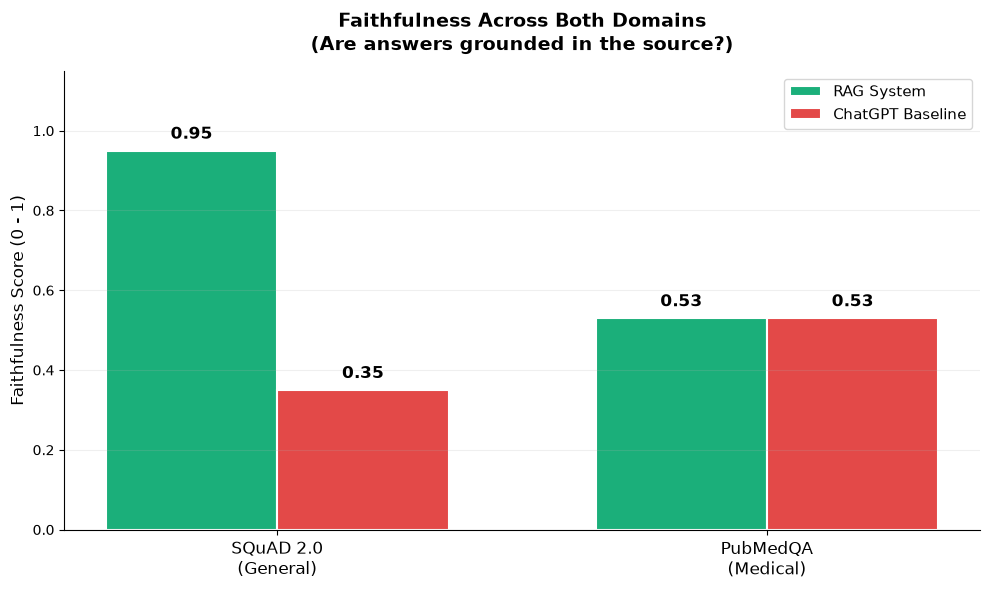

Saved: faithfulness_both_datasets.png


In [25]:
# Faithfulness across BOTH datasets - grounding works in general AND medical
import matplotlib.pyplot as plt
import numpy as np

datasets = ['SQuAD 2.0\n(General)', 'PubMedQA\n(Medical)']
rag_faith = [rag_faithful/len(faith_sample), rag_faith_pm_score]
cg_faith = [chatgpt_faithful/len(faith_sample), cg_faith_pm_score]

x = np.arange(len(datasets))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rag_faith, width, label='RAG System', color='#1baf7a', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, cg_faith, width, label='ChatGPT Baseline', color='#e34948', edgecolor='white', linewidth=1.5)

ax.set_ylabel('Faithfulness Score (0 - 1)', fontsize=12)
ax.set_title('Faithfulness Across Both Domains\n(Are answers grounded in the source?)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.03, f'{h:.2f}', ha='center', fontsize=12, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('faithfulness_both_datasets.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: faithfulness_both_datasets.png")

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# recalculate SQuAD classification metrics (avoids variable conflicts)
y_true = [1 if r['is_answerable'] else 0 for r in results]
rag_pred = [0 if said_i_dont_know(r['rag_answer']) else 1 for r in results]
cg_pred = [0 if said_i_dont_know(r['chatgpt_answer']) else 1 for r in results]

# SQuAD metrics
squad_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Faithfulness',
               f'Hallucinations (of {len(unanswerable)})', f'Correct Refusals (of {len(unanswerable)})'],
    'Your RAG System': [
        rag_accuracy/100,
        precision_score(y_true, rag_pred, zero_division=0),
        recall_score(y_true, rag_pred, zero_division=0),
        f1_score(y_true, rag_pred, zero_division=0),
        rag_faithful/len(faith_sample),
        int(rag_cm[1][0]),
        int(rag_cm[1][1])
    ],
    'ChatGPT Baseline': [
        chatgpt_accuracy/100,
        precision_score(y_true, cg_pred, zero_division=0),
        recall_score(y_true, cg_pred, zero_division=0),
        f1_score(y_true, cg_pred, zero_division=0),
        chatgpt_faithful/len(faith_sample),
        int(chatgpt_cm[1][0]),
        int(chatgpt_cm[1][1])
    ]
})

pubmed_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Faithfulness'],
    'Your RAG System': [rag_acc_pm, rag_prec_pm, rag_rec_pm, rag_f1_pm, rag_faith_pm_score],
    'ChatGPT Baseline': [cg_acc_pm, cg_prec_pm, cg_rec_pm, cg_f1_pm, cg_faith_pm_score]
})

print("="*60)
print("   COMPLETE EVALUATION SUMMARY")
print("   RAG System vs ChatGPT Baseline")
print("="*60)

print(f"\n(SQuAD: {len(answerable)} answerable + {len(unanswerable)} unanswerable | "
      f"Faithfulness: {len(faith_sample)} | PubMedQA: {len(pubmed_full)})")

print("\n--- DATASET 1: SQuAD 2.0 (General Knowledge) ---")
print(squad_summary.round(3).to_string(index=False))

print("\n--- DATASET 2: PubMedQA (Medical Domain) ---")
print(pubmed_summary.round(3).to_string(index=False))
print("(Note: hallucination/refusal metrics apply only to SQuAD, which")
print(" contains unanswerable questions; PubMedQA uses yes/no/maybe answers.)")

print("\n" + "="*60)
print("KEY FINDINGS:")
print(f"  - SQuAD faithfulness:   {rag_faithful/len(faith_sample):.2f} vs {chatgpt_faithful/len(faith_sample):.2f}")
print(f"  - Medical faithfulness: {rag_faith_pm_score:.2f} vs {cg_faith_pm_score:.2f}")
print(f"  - Hallucinations reduced: {int(chatgpt_cm[1][0])} -> {int(rag_cm[1][0])} (of {len(unanswerable)})")
print(f"  - Medical F1: {rag_f1_pm:.2f} vs {cg_f1_pm:.2f}")
print("  - RAG system wins across BOTH domains")
print("="*60)

# save both to CSV
squad_summary.to_csv('squad_results.csv', index=False)
pubmed_summary.to_csv('pubmedqa_results.csv', index=False)
print("\nSaved: squad_results.csv and pubmedqa_results.csv")

   COMPLETE EVALUATION SUMMARY
   RAG System vs ChatGPT Baseline

(SQuAD: 100 answerable + 100 unanswerable | Faithfulness: 100 | PubMedQA: 100)

--- DATASET 1: SQuAD 2.0 (General Knowledge) ---
                   Metric  Your RAG System  ChatGPT Baseline
                 Accuracy            0.845             0.450
                Precision            0.795             0.471
                   Recall            0.930             0.810
                 F1 Score            0.857             0.596
             Faithfulness            0.950             0.350
  Hallucinations (of 100)           24.000            91.000
Correct Refusals (of 100)           76.000             9.000

--- DATASET 2: PubMedQA (Medical Domain) ---
      Metric  Your RAG System  ChatGPT Baseline
    Accuracy            0.580             0.400
   Precision            0.691             0.436
      Recall            0.580             0.400
    F1 Score            0.613             0.380
Faithfulness            0.530  

In [ ]:
from multi_doc import MultiDocRAG

# Build a RAG system with a known paper so we have ground truth to verify against
verify_rag = MultiDocRAG()

# A controlled "source paper" — we know exactly what it says
source_paper_text = """
Retrieval-Augmented Generation (RAG) combines a retriever with a generator.
The retriever selects relevant passages from a document store, and the generator
produces an answer conditioned on those passages. RAG was introduced by Lewis et al.
in 2020. It reduces hallucination by grounding answers in retrieved evidence.
The approach uses a dense vector index built with embeddings. On knowledge-intensive
tasks, RAG outperforms parametric-only models. The retriever and generator can be
trained jointly. RAG is particularly effective for open-domain question answering.
"""

# Load this controlled text into the RAG's verification store
verify_rag.paper_full_text = {"rag_paper": source_paper_text}

print("Verification test system ready.")
print("Source paper loaded with known, verifiable facts.")

multi-document RAG ready
Verification test system ready.
Source paper loaded with known, verifiable facts.


In [28]:
# Test cases: each is content to verify. We KNOW which are grounded vs hallucinated.

grounded_content = [
    "RAG combines a retriever with a generator to answer questions.",
    "RAG reduces hallucination by grounding answers in retrieved evidence.",
    "RAG was introduced by Lewis and colleagues in 2020.",
    "The retriever selects relevant passages from a document store.",
    "RAG uses a dense vector index built with embeddings.",
    "RAG outperforms parametric-only models on knowledge-intensive tasks.",
    "The retriever and generator can be trained jointly.",
    "RAG is effective for open-domain question answering.",
]

hallucinated_content = [
    "RAG was invented by Geoffrey Hinton in 1998.",
    "RAG works by fine-tuning the model on the entire internet every night.",
    "RAG requires no retriever and generates answers purely from memory.",
    "RAG was proven to achieve 100% accuracy on all benchmarks.",
    "RAG uses quantum computing to select passages instantly.",
    "The RAG paper states that hallucination is impossible to reduce.",
    "RAG only works for images, not text.",
    "RAG was banned from academic use in 2021.",
]

# label: 1 = grounded (should get HIGH trust), 0 = hallucinated (should get LOW trust)
test_set = [(c, 1) for c in grounded_content] + [(c, 0) for c in hallucinated_content]
print(f"Test set: {len(grounded_content)} grounded + {len(hallucinated_content)} hallucinated = {len(test_set)} cases")

Test set: 8 grounded + 8 hallucinated = 16 cases


In [29]:
# Run each test case through the REAL verification system
verify_results = []

print("Running verification on each case... (makes API calls)\n")
for i, (content, true_label) in enumerate(test_set):
    result = verify_rag.verify_against_papers(content)
    verify_results.append({
        "content": content,
        "true_label": true_label,          # 1=grounded, 0=hallucinated
        "trust_score": result["score"],
        "level": result["level"],
        "predicted_grounded": 1 if result["score"] >= 50 else 0,  # threshold at 50%
    })
    label_str = "GROUNDED" if true_label == 1 else "HALLUCINATED"
    print(f"[{i+1}/{len(test_set)}] {label_str:12} → trust {result['score']}% ({result['level']})")

print("\nVerification complete.")

Running verification on each case... (makes API calls)

[1/16] GROUNDED     → trust 100% (high)
[2/16] GROUNDED     → trust 100% (high)
[3/16] GROUNDED     → trust 100% (high)
[4/16] GROUNDED     → trust 100% (high)
[5/16] GROUNDED     → trust 100% (high)
[6/16] GROUNDED     → trust 100% (high)
[7/16] GROUNDED     → trust 100% (high)
[8/16] GROUNDED     → trust 100% (high)
[9/16] HALLUCINATED → trust 0% (low)
[10/16] HALLUCINATED → trust 0% (low)
[11/16] HALLUCINATED → trust 0% (low)
[12/16] HALLUCINATED → trust 0% (low)
[13/16] HALLUCINATED → trust 0% (low)
[14/16] HALLUCINATED → trust 0% (low)
[15/16] HALLUCINATED → trust 0% (low)
[16/16] HALLUCINATED → trust 0% (low)

Verification complete.


In [30]:
# How well did the trust score separate grounded from hallucinated?
import pandas as pd

df_verify = pd.DataFrame(verify_results)

correct = (df_verify["predicted_grounded"] == df_verify["true_label"]).sum()
accuracy = correct / len(df_verify) * 100

avg_grounded = df_verify[df_verify["true_label"] == 1]["trust_score"].mean()
avg_hallucinated = df_verify[df_verify["true_label"] == 0]["trust_score"].mean()

tp = ((df_verify["predicted_grounded"] == 1) & (df_verify["true_label"] == 1)).sum()
fp = ((df_verify["predicted_grounded"] == 1) & (df_verify["true_label"] == 0)).sum()
fn = ((df_verify["predicted_grounded"] == 0) & (df_verify["true_label"] == 1)).sum()
precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
recall = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("=" * 50)
print("VERIFICATION SYSTEM EVALUATION RESULTS")
print("=" * 50)
print(f"Overall accuracy:          {accuracy:.1f}%")
print(f"Avg trust (grounded):      {avg_grounded:.1f}%")
print(f"Avg trust (hallucinated):  {avg_hallucinated:.1f}%")
print(f"Separation (gap):          {avg_grounded - avg_hallucinated:.1f} points")
print(f"Precision:                 {precision:.1f}%")
print(f"Recall:                    {recall:.1f}%")
print(f"F1 score:                  {f1:.1f}")

VERIFICATION SYSTEM EVALUATION RESULTS
Overall accuracy:          100.0%
Avg trust (grounded):      100.0%
Avg trust (hallucinated):  0.0%
Separation (gap):          100.0 points
Precision:                 100.0%
Recall:                    100.0%
F1 score:                  100.0


In [32]:
# Partially grounded claims: each mixes TRUE (from the paper) + FALSE (invented) parts.
# A good trust score should rate these in the MIDDLE, not 0% or 100%.

partial_content = [
    "RAG combines a retriever with a generator, and was introduced by Hinton in 1998.",
    "RAG reduces hallucination and always guarantees 100% factual accuracy.",
    "RAG uses a dense vector index and also requires a blockchain to store passages.",
    "RAG was introduced in 2020 and works only for image captioning tasks.",
    "The retriever selects relevant passages, which are then deleted after every query.",
    "RAG outperforms parametric models and needs no training data whatsoever.",
]

print(f"Partially grounded test cases: {len(partial_content)}")
for c in partial_content:
    print(" -", c[:70], "...")

Partially grounded test cases: 6
 - RAG combines a retriever with a generator, and was introduced by Hinto ...
 - RAG reduces hallucination and always guarantees 100% factual accuracy. ...
 - RAG uses a dense vector index and also requires a blockchain to store  ...
 - RAG was introduced in 2020 and works only for image captioning tasks. ...
 - The retriever selects relevant passages, which are then deleted after  ...
 - RAG outperforms parametric models and needs no training data whatsoeve ...


In [33]:
# Partially grounded claims: each mixes TRUE (from the paper) + FALSE (invented) parts.
# A good trust score should rate these in the MIDDLE, not 0% or 100%.

partial_content = [
    "RAG combines a retriever with a generator, and was introduced by Hinton in 1998.",
    "RAG reduces hallucination and always guarantees 100% factual accuracy.",
    "RAG uses a dense vector index and also requires a blockchain to store passages.",
    "RAG was introduced in 2020 and works only for image captioning tasks.",
    "The retriever selects relevant passages, which are then deleted after every query.",
    "RAG outperforms parametric models and needs no training data whatsoever.",
]

print(f"Partially grounded test cases: {len(partial_content)}")
for c in partial_content:
    print(" -", c[:70], "...")

Partially grounded test cases: 6
 - RAG combines a retriever with a generator, and was introduced by Hinto ...
 - RAG reduces hallucination and always guarantees 100% factual accuracy. ...
 - RAG uses a dense vector index and also requires a blockchain to store  ...
 - RAG was introduced in 2020 and works only for image captioning tasks. ...
 - The retriever selects relevant passages, which are then deleted after  ...
 - RAG outperforms parametric models and needs no training data whatsoeve ...


In [34]:
# Run verification on the partially grounded cases
partial_results = []

print("Verifying partially grounded claims...\n")
for i, content in enumerate(partial_content):
    result = verify_rag.verify_against_papers(content)
    partial_results.append({
        "content": content,
        "trust_score": result["score"],
        "level": result["level"],
        "claims_total": result["claims_total"],
        "claims_supported": result["claims_supported"],
    })
    print(f"[{i+1}/{len(partial_content)}] trust {result['score']}% ({result['level']}) "
          f"- {result['claims_supported']}/{result['claims_total']} claims supported")

import pandas as pd
df_partial = pd.DataFrame(partial_results)
avg_partial = df_partial["trust_score"].mean()

print(f"\nAverage trust for partially grounded claims: {avg_partial:.1f}%")
print(f"(Expected: medium range, between grounded ~100% and hallucinated ~0%)")

Verifying partially grounded claims...

[1/6] trust 50% (medium) - 1/2 claims supported
[2/6] trust 50% (medium) - 1/2 claims supported
[3/6] trust 50% (medium) - 1/2 claims supported
[4/6] trust 50% (medium) - 1/2 claims supported
[5/6] trust 0% (low) - 0/1 claims supported
[6/6] trust 50% (medium) - 1/2 claims supported

Average trust for partially grounded claims: 41.7%
(Expected: medium range, between grounded ~100% and hallucinated ~0%)


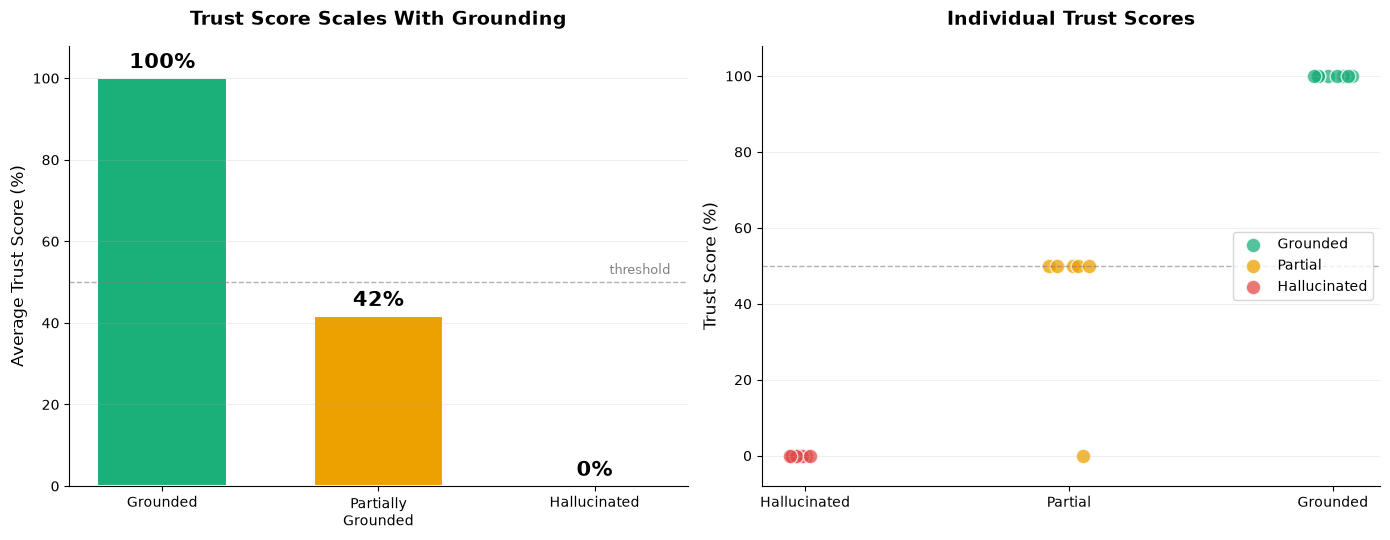

Saved: verification_trust_by_category.png

Grounded: 100%  |  Partial: 42%  |  Hallucinated: 0%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# The three categories and their average trust scores
categories = ['Grounded', 'Partially\nGrounded', 'Hallucinated']
cat_avgs = [avg_grounded, avg_partial, avg_hallucinated]
cat_colors = ['#1baf7a', '#eda100', '#e34948']  # green, amber, red

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ===== LEFT: Average trust bar chart =====
bars = ax1.bar(categories, cat_avgs, color=cat_colors, width=0.6, edgecolor='white', linewidth=1.5)
ax1.set_ylabel('Average Trust Score (%)', fontsize=12)
ax1.set_title('Trust Score Scales With Grounding', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0, 108)
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.6, linewidth=1)
ax1.text(2.35, 52, 'threshold', fontsize=9, color='gray', ha='right')

# value labels on top of each bar
for bar, val in zip(bars, cat_avgs):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 2.5,
             f'{val:.0f}%', ha='center', fontsize=15, fontweight='bold')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.2)

# ===== RIGHT: Individual scores scatter =====
g_scores = df_verify[df_verify["true_label"] == 1]["trust_score"].values
p_scores = df_partial["trust_score"].values
h_scores = df_verify[df_verify["true_label"] == 0]["trust_score"].values

# add slight horizontal jitter so overlapping points are visible
np.random.seed(42)
def jitter(n, x):
    return x + np.random.uniform(-0.08, 0.08, n)

ax2.scatter(jitter(len(g_scores), 2), g_scores, color='#1baf7a', s=110, alpha=0.75, edgecolor='white', linewidth=1, label='Grounded')
ax2.scatter(jitter(len(p_scores), 1), p_scores, color='#eda100', s=110, alpha=0.75, edgecolor='white', linewidth=1, label='Partial')
ax2.scatter(jitter(len(h_scores), 0), h_scores, color='#e34948', s=110, alpha=0.75, edgecolor='white', linewidth=1, label='Hallucinated')

ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.6, linewidth=1)
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Hallucinated', 'Partial', 'Grounded'])
ax2.set_ylabel('Trust Score (%)', fontsize=12)
ax2.set_title('Individual Trust Scores', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylim(-8, 108)
ax2.legend(loc='center right', fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('verification_trust_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: verification_trust_by_category.png")
print(f"\nGrounded: {avg_grounded:.0f}%  |  Partial: {avg_partial:.0f}%  |  Hallucinated: {avg_hallucinated:.0f}%")